# Homework

Let’s take the data-visualisation techniques we learned and use them on a real dataset you’re already familiar with. You’ll see how visualisation speeds up data cleaning, helps us spot patterns faster, and makes communicating insights much easier.

# **Apartment cost and sizes in Germany**

**Where is the data from?**

The data was scraped from Immoscout24, the biggest real estate platform in Germany. Immoscout24 has listings for both rental properties and homes for sale, however, the data only contains offers for rental properties.
The scraping process is described in this blog post and the corresponding code for scraping and minimal processing afterwards can be found in this Github repo.
At a given time, all available offers were scraped from the site and saved. This process was repeated three times, so the data set contains offers from the dates 2018-09-22, 2019-05-10 and 2019-10-08.

**Content**

The data set contains most of the important properties, such as living area size, the rent, both base rent as well as total rent (if applicable), the location (street and house number, if available, ZIP code and state), type of energy etc. It also has two variables containing longer free text descriptions: description with a text describing the offer and facilities describing all available facilities, newest renovation etc. The date column was added to give the time of scraping.

**Inspiration**

Did rents increase over time? Which areas are the most expensive? Which areas saw the largest increase, which areas became cheaper? Are there any duplicates? How many? What could be gained from a text analysis of the free text variables?

**Acknowledgements**

The data belongs to www.immobilienscount24.de and is for research purposes only. The data was created with .


**Here you can find the data -->**

https://www.kaggle.com/datasets/corrieaar/apartment-rental-offers-in-germany


Let's first read the data:

In [ ]:
import pandas as pd
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("corrieaar/apartment-rental-offers-in-germany")
csv_path = f"{path}/immo_data.csv"
df = pd.read_csv(csv_path)

Using Colab cache for faster access to the 'apartment-rental-offers-in-germany' dataset.


### Is the dataset complete?

1. Let's check **% of null values for each column** using a *barplot*

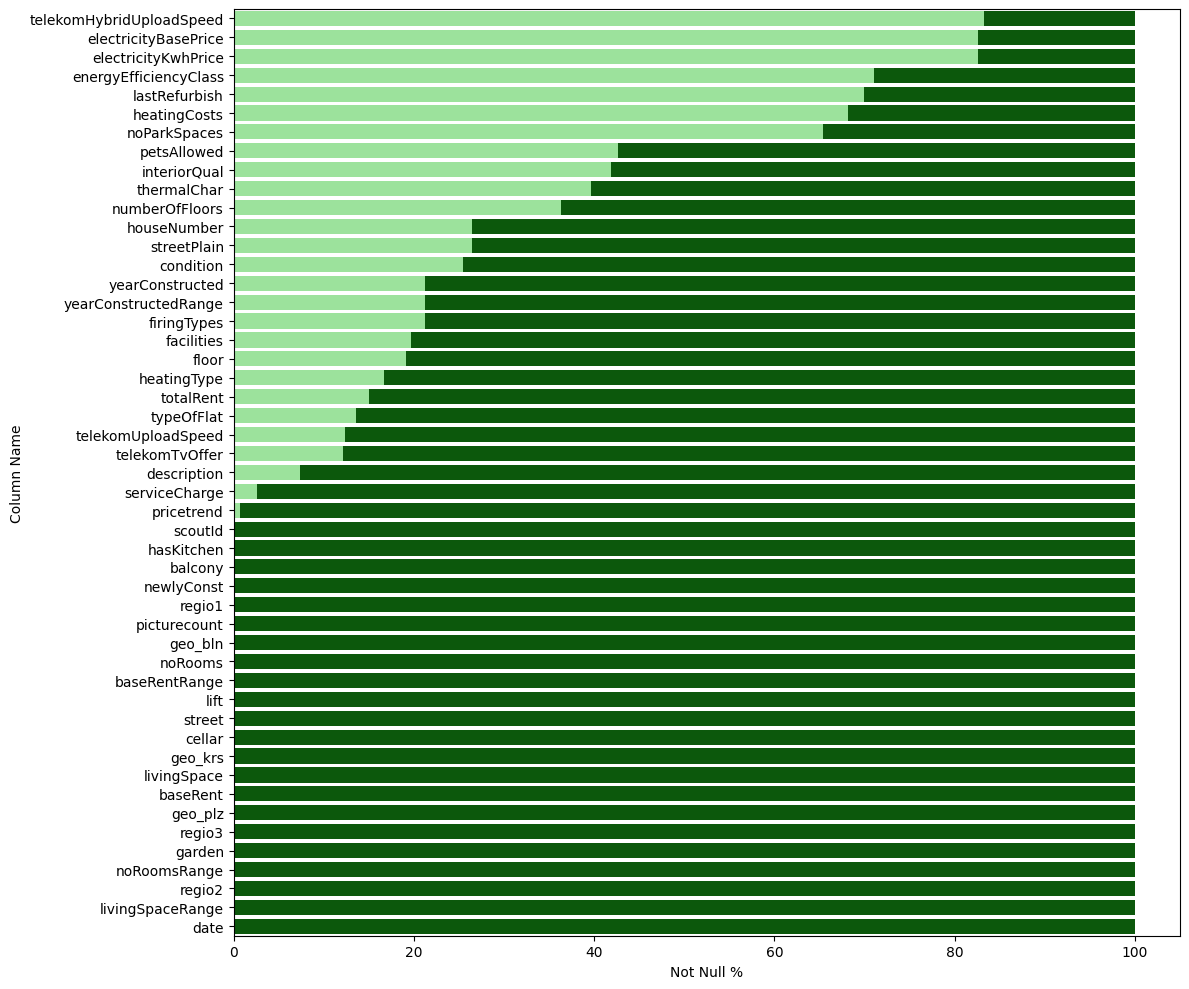

In [ ]:
null_percentage = df.isna().sum()/len(df)*100
completeness_df = pd.DataFrame({
    'Column Name': df.columns,
    'Null %': null_percentage,
    'Not Null %': 100 })
completeness_df = completeness_df.sort_values(by='Null %', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(y= 'Column Name',x=  'Not Null %', data = completeness_df, color ='darkgreen' )
sns.barplot(y= 'Column Name',x= 'Null %', data = completeness_df, color ='lightgreen' )
plt.xticks()
plt.tight_layout()

2. **Number of listings per date** (to check whether some dates have too little data to be meaningful, or whether the timeline is unevenly populated and could distort the overall picture) using a *lineplot*

In [ ]:
df.columns

Index(['regio1', 'serviceCharge', 'heatingType', 'telekomTvOffer',
       'telekomHybridUploadSpeed', 'newlyConst', 'balcony', 'picturecount',
       'pricetrend', 'telekomUploadSpeed', 'totalRent', 'yearConstructed',
       'scoutId', 'noParkSpaces', 'firingTypes', 'hasKitchen', 'geo_bln',
       'cellar', 'yearConstructedRange', 'baseRent', 'houseNumber',
       'livingSpace', 'geo_krs', 'condition', 'interiorQual', 'petsAllowed',
       'street', 'streetPlain', 'lift', 'baseRentRange', 'typeOfFlat',
       'geo_plz', 'noRooms', 'thermalChar', 'floor', 'numberOfFloors',
       'noRoomsRange', 'garden', 'livingSpaceRange', 'regio2', 'regio3',
       'description', 'facilities', 'heatingCosts', 'energyEfficiencyClass',
       'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice', 'date'],
      dtype='object')

In [ ]:
df['date'].unique()

array(['May19', 'Oct19', 'Feb20', 'Sep18'], dtype=object)

In [ ]:
df1 = df["date"].value_counts().reset_index( name = 'count')
df1

,date,count
0,Feb20,79276
1,May19,76047
2,Oct19,66685
3,Sep18,46842


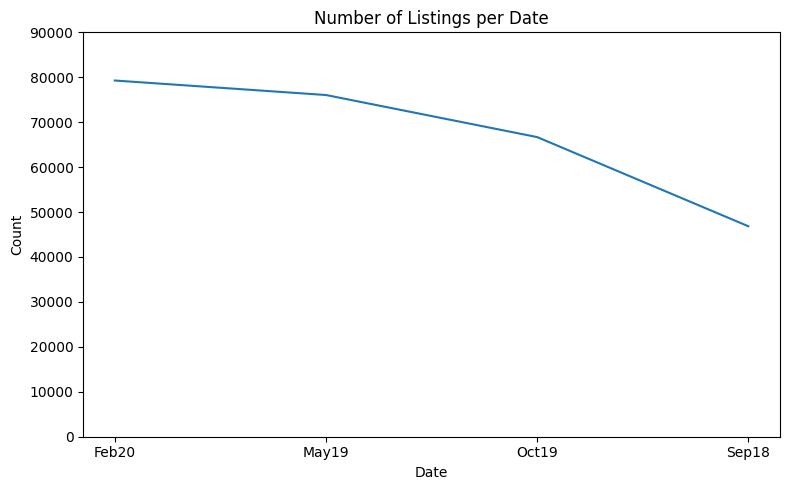

In [ ]:
#df = pd.DataFrame({"date": ['May19', 'Oct19', 'Feb20', 'Sep18']})
#df['date_datetime'] = pd.to_datetime(df["date"], format ="%b%y")
#date_counts = df['date_datetime'].value_counts().reset_index()
#date_counts.columns = ['date_datetime', 'count']

plt.figure(figsize=(8,5))
sns.lineplot(x='date' , y='count' , data= df1)

plt.ylim(0, 90000)
plt.title('Number of Listings per Date')
plt.ylabel('Count')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

3. Let's check which **condition types** are the flats in, using *countplot*

Text(0.5, 1.0, 'apartment_condition_types')

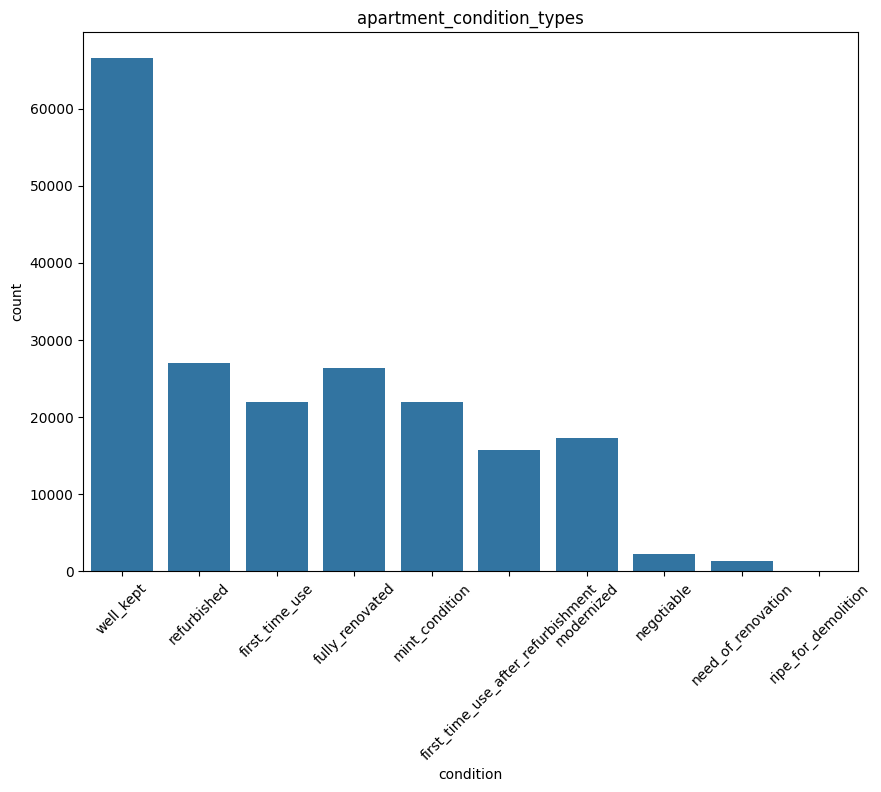

In [ ]:
plt.figure(figsize= (10,7))
sns.countplot(data = df, x= 'condition')
plt.xticks(rotation=45)
plt.tight_layout
plt.title('apartment_condition_types')

### Statistical analysis

1. *Heatmap* showing the **correlation coefficients** between all numeric fields in the dataset.

Text(0.5, 1.0, 'correlation coefficients between numerical values')

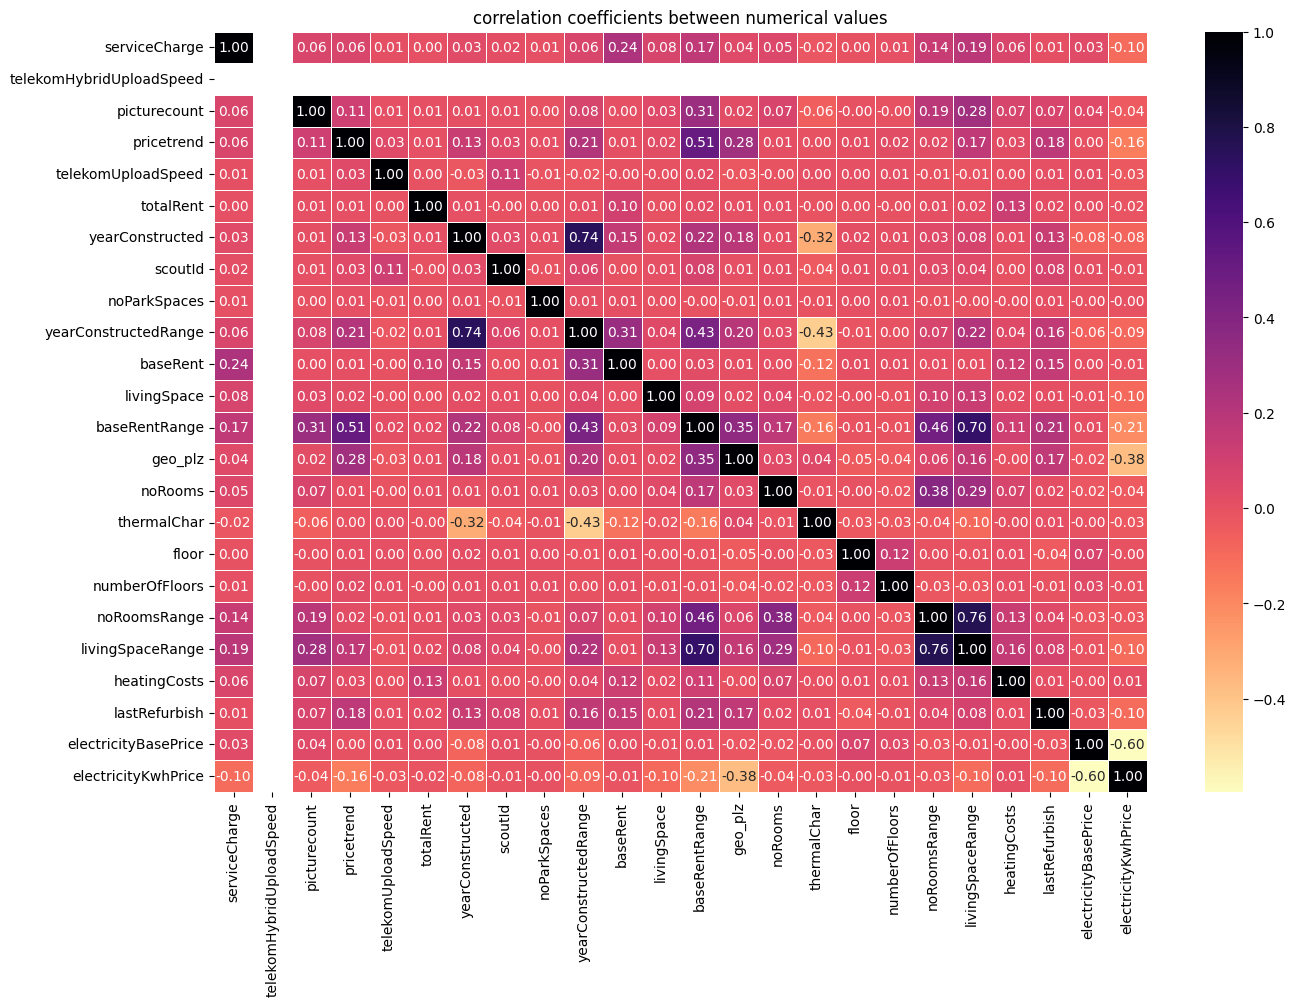

In [ ]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])
correlation_df = numerical_df.corr()
plt.figure(figsize=(14,10))
sns.heatmap(correlation_df, annot=True, cmap='magma_r', fmt='.2f', linewidths=0.7)
plt.tight_layout()
plt.title('correlation coefficients between numerical values')

In [ ]:
#df['totalRent'].max()
df_berlin = df[df['regio2'] == 'Berlin']
df_berlin.groupby('regio2')[['totalRent']].min()

,totalRent
regio2,
Berlin,0.0


In [ ]:
df['livingSpace'].max()

111111.0

2. *Scatterplot* of **living space vs total rent for Berlin**

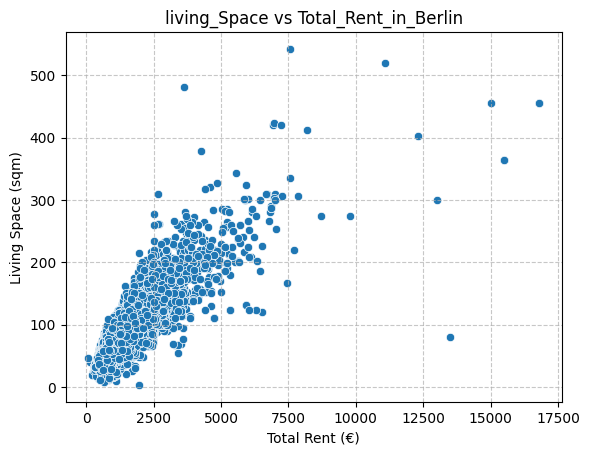

In [ ]:
df_berlin_filtered = df_berlin[(df_berlin['livingSpace'] > 0) & (df_berlin['livingSpace'] < 560) &
                                 (df_berlin['totalRent'] > 0) & (df_berlin['totalRent'] < 51000)]

sns.scatterplot(data=df_berlin_filtered, y="livingSpace", x="totalRent")
plt.title("living_Space vs Total_Rent_in_Berlin")
plt.ylabel('Living Space (sqm)')
plt.xlabel('Total Rent (€)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



3. *Histogram* of **total rent values** for Berlin

<Axes: xlabel='totalRent', ylabel='Count'>

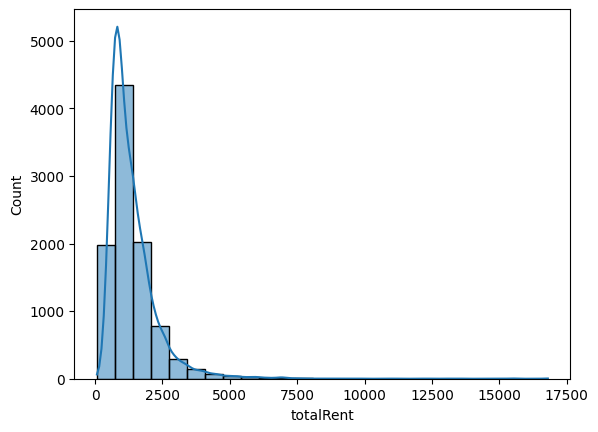

In [ ]:
sns.histplot(df_berlin_filtered['totalRent'], bins = 25, kde=True)

### Additional Questions

1. Create a heatmap after removing outliers and entries with 0 values. Does the correlation pattern change, and why?

Text(0.5, 1.0, 'Correlation Heatmap After Removing Zero Values')

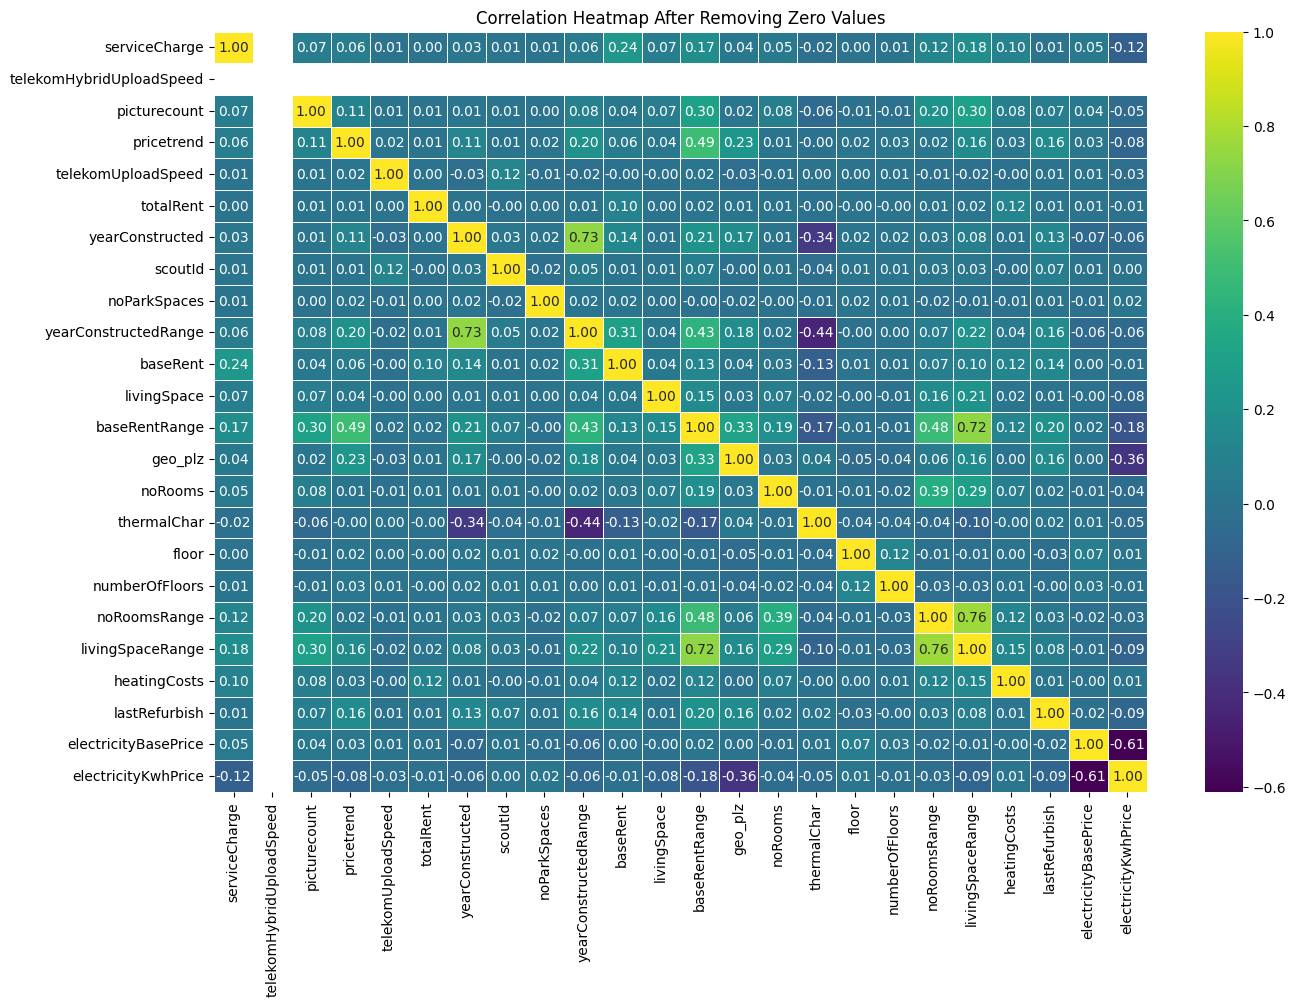

In [ ]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])
numerical_df1 = numerical_df[(numerical_df != 0).all(axis=1)]
plt.figure(figsize=(14,10))
sns.heatmap(numerical_df1.corr(), annot=True, cmap='viridis', fmt='.2f', linewidths=0.7)
plt.tight_layout()
plt.title('Correlation Heatmap After Removing Zero Values')


In [ ]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])
numerical_df1 = numerical_df[(numerical_df != 0).all(axis=1) & ]
plt.figure(figsize=(14,10))
sns.heatmap(numerical_df1.corr(), annot=True, cmap='viridis', fmt='.2f', linewidths=0.7)
plt.tight_layout()
plt.title('Correlation Heatmap After Removing Zero Values')


In [ ]:
df['totalRent'].max()

15751535.0

2. Draw scatterplots for two more variable pairs that show high correlation or seem interesting to explore further.

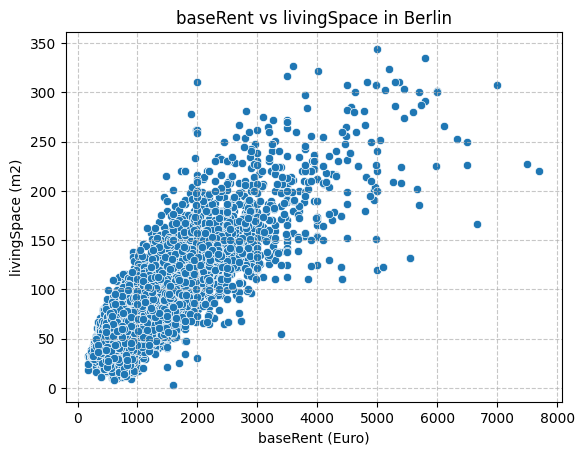

In [ ]:
df1_berlin = df[df['regio2']== 'Berlin' ]
df1_berlin_filtered = df1_berlin[(df1_berlin['baseRent'] > 1) & (df1_berlin['baseRent'] < 8000) &
                                (df1_berlin['livingSpace'] > 0) & (df1_berlin['livingSpace'] < 350)]

sns.scatterplot(data= df1_berlin_filtered ,x = 'baseRent', y = 'livingSpace')
plt.title("baseRent vs livingSpace in Berlin")
plt.xlabel('baseRent (Euro)' )
plt.ylabel('livingSpace (m2)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# There is a strong positive correlation between  baseRent and livingSPace as expected. The higher the livingSpace, the higher the BaseRent

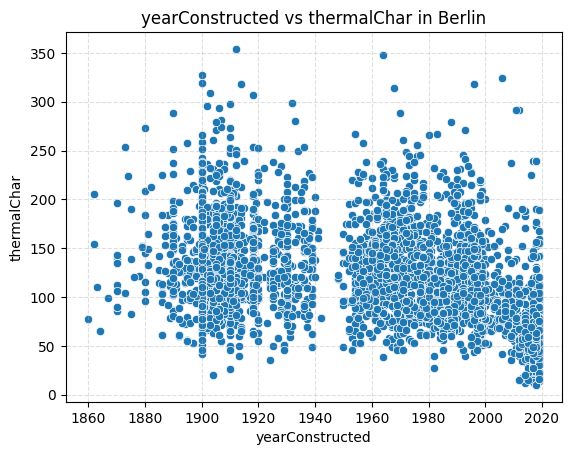

In [ ]:
df1_berlin = df[df['regio2']== 'Berlin' ]
df1_berlin_filtered = df1_berlin[(df1_berlin['yearConstructed'] > 1850) & (df1_berlin['yearConstructed'] < 2020) &
                                (df1_berlin['thermalChar'] > 1) & (df1_berlin['thermalChar'] < 380)]

sns.scatterplot(data= df1_berlin_filtered ,x = 'yearConstructed', y = 'thermalChar')
plt.title("yearConstructed vs thermalChar in Berlin")
plt.xlabel('yearConstructed')
plt.ylabel('thermalChar')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

3. Calculate and visualize the average price for each apartment condition to see how it affects pricing.

In [ ]:
df3 = df.groupby('condition')["baseRent"].mean().reset_index(name = 'baseRent')
df3

,condition,baseRent
0,first_time_use,1089.246699
1,first_time_use_after_refurbishment,780.391517
2,fully_renovated,584.237845
3,mint_condition,975.435557
4,modernized,575.762533
5,need_of_renovation,530.557106
6,negotiable,484.048513
7,refurbished,494.975149
8,ripe_for_demolition,782.125000
9,well_kept,548.610914


Text(0.5, 14.722222222222216, 'baseRent(Euro)')

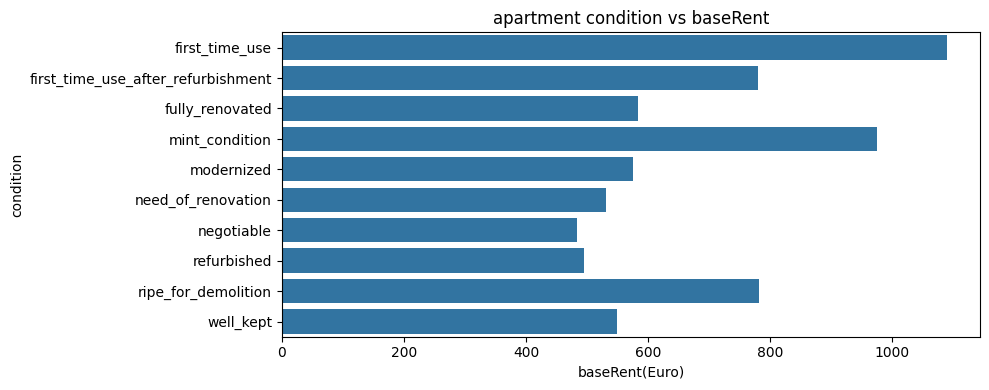

In [ ]:
plt.figure(figsize=(10,4))
sns.barplot(data = df3, y = 'condition', x ='baseRent')
plt.title('apartment condition vs baseRent')
plt.tight_layout()
plt.xlabel('baseRent(Euro)')
#plt.ylabel()

#insights
#Apartments in conditions such as “first_time_use”, “refurbished”, or “mint condition”  show high average base rent with first_time_use having
#the highest average cost. It simply means that apartment condition is a strong predictor of rent.

4. Examine the correlation between the number of listing pictures and price. Could this be coincidence, or is there a reason behind it?

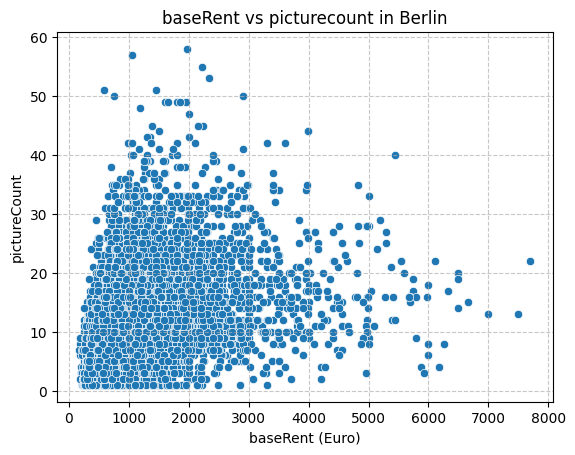

In [ ]:
df1_berlin = df[df['regio2']== 'Berlin' ]
df1_berlin_filtered = df1_berlin[(df1_berlin['baseRent'] > 1) & (df1_berlin['baseRent'] < 8000) &
                                (df1_berlin['picturecount'] > 0) & (df1_berlin['picturecount'] < 60)]

sns.scatterplot(data= df1_berlin_filtered ,x = 'baseRent', y = 'picturecount')
plt.title("baseRent vs picturecount in Berlin")
plt.xlabel('baseRent (Euro)' )
plt.ylabel('pictureCount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#From the scatterplot, there seems to be weak correlation. It simply means the pictures posted does not necessarily influence baseRent of an apartment.